In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sympy import symbols, groebner
import pandas as pd

In [2]:
#Datos anteriores
m1  = 0.1180850933
m2  = 0.1619481497
m3  = 0.0771816605
v1   = 0.03492332644
v2   = 0.02776645397
v3   = 0.03505910984
cv12 = 0.001666029016
cv13 = 0.0005078163229
cv23 = 0.0005112105901

In [3]:
#grober sino va muy lento
v1 = sp.Rational(v1)
v2 = sp.Rational(v2)
v3 = sp.Rational(v3)
cv12 = sp.Rational(cv12)
cv13 = sp.Rational(cv13)
cv23 = sp.Rational(cv23)
m1 = sp.Rational(m1)
m2 = sp.Rational(m2)
m3 = sp.Rational(m3)


In [4]:
 #ponemos las incognitas, y creamos la ecuacion de reestriccion
p1, p2, lam, E ,V = sp.symbols('p1 p2 lambda E V')
p3 = 1 - p1 - p2

In [5]:
#formula de la varianza, nuestro f
f = (v1*p1**2 + v2*p2**2 + v3*p3**2
     + 2*cv12*p1*p2 + 2*cv13*p1*p3 + 2*cv23*p2*p3) 
#esta es la reestriccion, la llamo g
g = m1*p1 + m2*p2 + m3*p3 - E

In [6]:
# derivadas parciales de el multiplicador de lagrange
# el sistema es: derivada parcial respecto al peso i - lambda * 
pol1 = sp.diff(f, p1) - lam*sp.diff(g, p1)
print(f"polinomio 1 de lagrange: {pol1}")
pol2 = sp.diff(f, p2) - lam*sp.diff(g, p2)
print(f"polinomio 2 de lagrange: {pol2}")
pol3 = g
print(f"polinomio reestriccion: {pol3}")
pol4 = V -f
print(f"polinomio para la frontera eficiente: {pol4}")
pol_sum = p1 + p2 + p3 - 1

polinomio 1 de lagrange: -1473701477730033*lambda/36028797018963968 + 79513311013866823*p1/576460752303423488 + 329330754439872529*p2/4611686018427387904 - 79669858615695455/1152921504606846976
polinomio 2 de lagrange: -3054034633397001*lambda/36028797018963968 + 329330754439872529*p1/4611686018427387904 + 285016688760722319*p2/2305843009213693952 - 318648127873603727/4611686018427387904
polinomio reestriccion: -E + 1473701477730033*p1/36028797018963968 + 3054034633397001*p2/36028797018963968 + 2780762379741089/36028797018963968
polinomio para la frontera eficiente: V - 2516490879067555*p1**2/72057594037927936 - 7683202719381539*p1*p2/2305843009213693952 - 1170944718123569*p1*(-p1 - p2 + 1)/1152921504606846976 - 4001567736086145*p2**2/144115188075855872 - 4715085461672369*p2*(-p1 - p2 + 1)/4611686018427387904 - 5052550208363689*(-p1 - p2 + 1)**2/144115188075855872


In [7]:
#Aplicamos groebner
G = sp.groebner(
    [pol1, pol2, pol3, pol_sum, pol4],
    [p1, p2, p3, lam, V],
    order='lex'
)
print(G)

GroebnerBasis([497583204507622428894883250677738505364727398400*E/350548453481828073867198363498558650373938491371 + p1 - 166588700976295874849785592400681653096565735592/350548453481828073867198363498558650373938491371, -1458521789881302576132704911204036135883454283776*E/116849484493942691289066121166186216791312830457 + p2 + 133189273971793852042745616835672906524388914185/116849484493942691289066121166186216791312830457, -17883736703702730676893932778371045185828016881664*E/1051645360445484221601595090495675951121815474113 + lambda + 279570327546713074559876737301764723759296931223917/134610606137021980365004171583446521743592380686464, -8941868351851365338446966389185522592914008440832*E**2/1051645360445484221601595090495675951121815474113 + 279570327546713074559876737301764723759296931223917*E/134610606137021980365004171583446521743592380686464 + V - 335045377141785792886526326822137741549014760591423923570029755899/2424929102555235171175904826535865361015482551278061108094960664

In [8]:
#Observamos la base, esta en forma de fraccion
print(G[0])

497583204507622428894883250677738505364727398400*E/350548453481828073867198363498558650373938491371 + p1 - 166588700976295874849785592400681653096565735592/350548453481828073867198363498558650373938491371


In [9]:
#Sacamos la base de groibner que solo depende de E y V
for poly in G:
    if poly.free_symbols == {E, V}:
        frontera = poly
        break

print(frontera)

-8941868351851365338446966389185522592914008440832*E**2/1051645360445484221601595090495675951121815474113 + 279570327546713074559876737301764723759296931223917*E/134610606137021980365004171583446521743592380686464 + V - 335045377141785792886526326822137741549014760591423923570029755899/2424929102555235171175904826535865361015482551278061108094960664576


In [10]:
#Con el metodo de multiplicadores de lagrange, tenemos un polinomio solo en funcion de V y E, despejamos V respecto a E, y obtenemos los menores V respecto de E
V_E = sp.solve(frontera, V)[0]
print(V_E)

8941868351851365338446966389185522592914008440832*E**2/1051645360445484221601595090495675951121815474113 - 279570327546713074559876737301764723759296931223917*E/134610606137021980365004171583446521743592380686464 + 335045377141785792886526326822137741549014760591423923570029755899/2424929102555235171175904826535865361015482551278061108094960664576


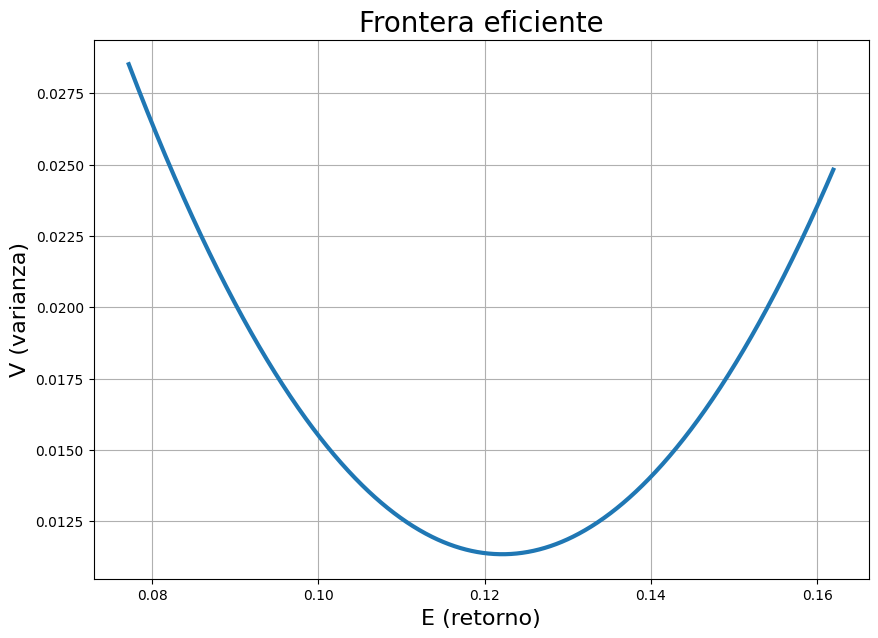

In [11]:
#Simplemente imprimimos la funcion, esta es la funcion con valores negativos de pesos (no filtrado)
V_func = sp.lambdify(E, V_E, "numpy")
#Acotramos E, que solo puede estar entre el E minimo y maximo
E_min = min(m1, m2, m3)
E_max = max(m1, m2, m3)

E_vals = np.linspace(E_min, E_max, 1000)
V_vals = V_func(E_vals)

plt.figure(figsize=(10,7))
plt.plot(E_vals, V_vals, linewidth=3)
plt.xlabel("E (retorno)", fontsize=16)
plt.ylabel("V (varianza)", fontsize=16)
plt.title("Frontera eficiente", fontsize=20)
plt.grid(True)
plt.show()

In [12]:
#Simplemente despejamos las funciones, respecto a p1 p2 y p3, ya que tenemos E y V, podemos resolver facilmente (se puede hacer con los de grobner tambien)
sol = sp.solve([pol1, pol2, pol3, pol_sum], [p1, p2, lam], dict=True)[0]
p1_expr = sol[p1]
p2_expr = sol[p2]
p3_expr = 1 - p1_expr - p2_expr

In [13]:
#pasamos el formato correcto (no se le pueden meter variables sino)
p1_func = sp.lambdify(E, p1_expr, "numpy")
p2_func = sp.lambdify(E, p2_expr, "numpy")
p3_func = sp.lambdify(E, p3_expr, "numpy")
E_vals_float = np.array(E_vals, dtype=float)
V_vals_float = np.array(V_vals, dtype=float)
p1_vals = p1_func(E_vals_float)
p2_vals = p2_func(E_vals_float)
p3_vals = p3_func(E_vals_float)

In [14]:
#Reestriccion de pesos positivos
mask = (p1_vals >= 0) & (p2_vals >= 0) & (p3_vals >= 0)

#Filtramos valores , quedan listas sin pesos negativos
E_res  = E_vals_float[mask]
V_res  = V_vals_float[mask]
p1_res = p1_vals[mask]
p2_res = p2_vals[mask]
p3_res = p3_vals[mask]
print(E_res)
print(V_res)

[0.09135183 0.09143669 0.09152154 0.09160639 0.09169124 0.09177609
 0.09186094 0.09194579 0.09203065 0.0921155  0.09220035 0.0922852
 0.09237005 0.0924549  0.09253975 0.0926246  0.09270946 0.09279431
 0.09287916 0.09296401 0.09304886 0.09313371 0.09321856 0.09330342
 0.09338827 0.09347312 0.09355797 0.09364282 0.09372767 0.09381252
 0.09389737 0.09398223 0.09406708 0.09415193 0.09423678 0.09432163
 0.09440648 0.09449133 0.09457619 0.09466104 0.09474589 0.09483074
 0.09491559 0.09500044 0.09508529 0.09517014 0.095255   0.09533985
 0.0954247  0.09550955 0.0955944  0.09567925 0.0957641  0.09584896
 0.09593381 0.09601866 0.09610351 0.09618836 0.09627321 0.09635806
 0.09644291 0.09652777 0.09661262 0.09669747 0.09678232 0.09686717
 0.09695202 0.09703687 0.09712173 0.09720658 0.09729143 0.09737628
 0.09746113 0.09754598 0.09763083 0.09771568 0.09780054 0.09788539
 0.09797024 0.09805509 0.09813994 0.09822479 0.09830964 0.0983945
 0.09847935 0.0985642  0.09864905 0.0987339  0.09881875 0.098903

In [15]:
#Sacamos el excel filtrado 
df_ok = pd.DataFrame({
    "E (Retorno)":    E_res,
    "V (Varianza)":   V_res,
    "Peso ETF1 (p1)": p1_res,
    "Peso ETF2 (p2)": p2_res,
    "Peso ETF3 (p3)": p3_res,
})

df_ok.to_excel("lagrange_filtrado.xlsx", index=False)

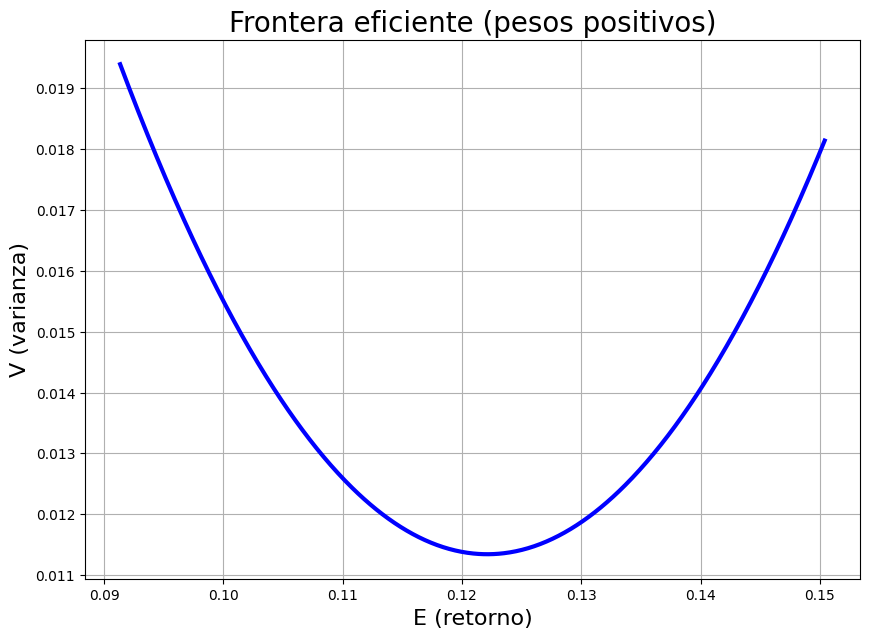

In [16]:
plt.figure(figsize=(10,7))
plt.plot(E_res, V_res, linewidth=3, color="blue")
plt.xlabel("E (retorno)", fontsize=16)
plt.ylabel("V (varianza)", fontsize=16)
plt.title("Frontera eficiente (pesos positivos)", fontsize=20)
plt.grid(True)
plt.show()

Se han generado numerosas combinaciones aleatorias de pesos para los activos. Total: 2000 combinaciones.


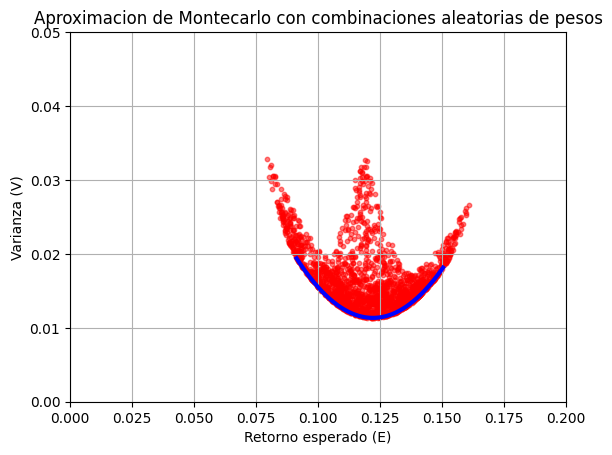

In [17]:
N = 2000
lista_monteCarlo = []

# Este comando da solamente los pesos que suman 1 y nos da valores aleatorios, que son carteras aleatorias
pesos = np.random.dirichlet(np.ones(3), size=N)

# Guardamos los pesos
for i in range(N):
    lista_monteCarlo.append((pesos[i][0], pesos[i][1], pesos[i][2]))
# Print para el tamaño, y ademas debbing para ver que se estan generando las combinaciones
print(f"Se han generado numerosas combinaciones aleatorias de pesos para los activos. Total: {N} combinaciones.")
plt.figure()

# Calulamos el retorno esperado y la varianza para cada combinacion de pesos, y los graficamos, para ver que caen debajo de la frontera eficiente
for i in range(len(lista_monteCarlo)):
    p1Carlo, p2Carlo, p3Carlo = lista_monteCarlo[i]
    E_random = m1*p1Carlo + m2*p2Carlo + m3*p3Carlo
    V_random = v1*p1Carlo**2 + v2*p2Carlo**2 + v3*p3Carlo**2 + 2*cv12*p1Carlo*p2Carlo + 2*cv13*p1Carlo*p3Carlo + 2*cv23*p2Carlo*p3Carlo
    plt.scatter(E_random, V_random, color='red', s=10, alpha=0.5)

# Hacemos el plot similar anterior, pero con un scatterplot (puntos de (E,V)) para ver que se aproxima bien
plt.xlabel("Retorno esperado (E)")
plt.ylabel("Varianza (V)")
plt.title("Aproximacion de Montecarlo con combinaciones aleatorias de pesos")
plt.plot(E_res, V_res, linewidth=3, color="blue")
plt.xlim(0, 0.2)
plt.ylim(0, 0.05)

plt.grid(True)

plt.savefig("aproxLagrange.png", dpi=300, bbox_inches="tight")
plt.show()
